In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score, roc_curve, confusion_matrix
import warnings
warnings.filterwarnings('ignore')


In [2]:
# Load dataset

file_path = 'Customer_Churn_Data_Large.xlsx'
x1 = pd.ExcelFile(file_path)
print("Available sheets:", x1.sheet_names)

Available sheets: ['Customer_Demographics', 'Transaction_History', 'Customer_Service', 'Online_Activity', 'Churn_Status']


In [4]:
# loading all sheets

df_demo = pd.read_excel(file_path,sheet_name = 'Customer_Demographics')
df_trans = pd.read_excel(file_path, sheet_name = 'Transaction_History')
df_service = pd.read_excel(file_path, sheet_name = 'Customer_Service')
df_online = pd.read_excel(file_path, sheet_name = 'Online_Activity')
df_churn = pd.read_excel(file_path, sheet_name = 'Churn_Status')

print("\nDataset Shape:")
print(f"Demographics: {df_demo.shape}")
print(f"Transactions: {df_trans.shape}")
print(f"Service: {df_service.shape}")
print(f"Online: {df_online.shape}")
print(f"Churn: {df_churn.shape}")


Dataset Shape:
Demographics: (1000, 5)
Transactions: (5054, 5)
Service: (1002, 5)
Online: (1000, 4)
Churn: (1000, 2)


In [5]:
# Data quality check

print("\nMising Values:")
for df, name in [(df_demo,'Demo'),(df_trans,'Trans'),(df_service,'Service'),(df_online,'Online'),(df_churn,'Churn')]:
 print(f"{name}:")
 print(f"{df.isnull().sum().sum()} missing values")



Mising Values:
Demo:
0 missing values
Trans:
0 missing values
Service:
0 missing values
Online:
0 missing values
Churn:
0 missing values


In [6]:
# 1. Descriptive Analysis

# Basic Information for each dataset
print("\nInfo: Customer Demographics")
df_demo.info()
print("\nInfo: Transaction History")
df_trans.info()
print("\nInfo: Customer Service")
df_service.info()
print("\nInfo: Online Activity ")
df_online.info()
print("\nInfo: Churn Status")
df_churn.info()

# Descriptive Statics - numeric columns
print("\n--- Numeric Summary : Customer Demographic---")
print(df_demo.describe())

print("\n--- Numeric Summary : Transaction History---")
print(df_trans.describe())

print("\n--- Numeric Summary : Customer Service---")
print(df_service.describe())

print("\n--- Numeric Summary : Online Activity---")
print(df_online.describe())

print("\n--- Numeric Summary : Churn Status---")
print(df_churn.describe())

print("\n--- Categorical Summary: Customer Demographics ---")
print(df_demo.describe(include=['object', 'category']))

print("\n--- Categorical Summary: Transaction History ---")
print(df_demo.describe(include=['object', 'category']))

print("\n--- Categorical Summary: Customer Service ---")
print(df_demo.describe(include=['object', 'category']))

print("\n--- Categorical Summary: Online Activity ---")
print(df_online.describe(include=['object', 'category']))


Info: Customer Demographics
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   CustomerID     1000 non-null   int64 
 1   Age            1000 non-null   int64 
 2   Gender         1000 non-null   object
 3   MaritalStatus  1000 non-null   object
 4   IncomeLevel    1000 non-null   object
dtypes: int64(2), object(3)
memory usage: 39.2+ KB

Info: Transaction History
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5054 entries, 0 to 5053
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   CustomerID       5054 non-null   int64         
 1   TransactionID    5054 non-null   int64         
 2   TransactionDate  5054 non-null   datetime64[ns]
 3   AmountSpent      5054 non-null   float64       
 4   ProductCategory  5054 non-null   object        
dtypes: da

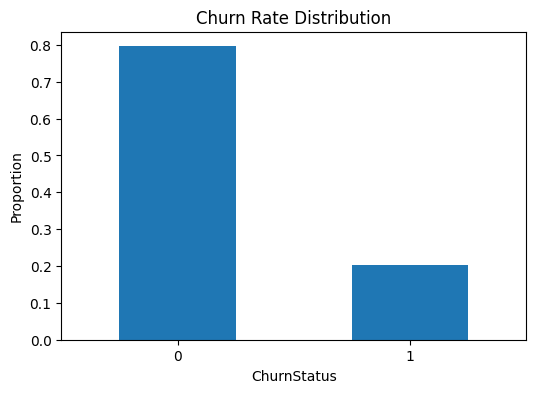

Churn Rate: ChurnStatus
0    0.796
1    0.204
Name: proportion, dtype: float64


In [7]:
# 1. Target Variable Analysis
plt.figure(figsize=(6,4))
df_churn['ChurnStatus'].value_counts(normalize=True).plot(kind='bar')
plt.title('Churn Rate Distribution')
plt.ylabel('Proportion')
plt.xticks(rotation = 0)
plt.show()
print("Churn Rate:", df_churn['ChurnStatus'].value_counts(normalize=True))

Churn Rate by Gender:
 Gender
F    19.688109
M    21.149897
Name: ChurnStatus, dtype: float64


(0.0, 23.26488706365503)

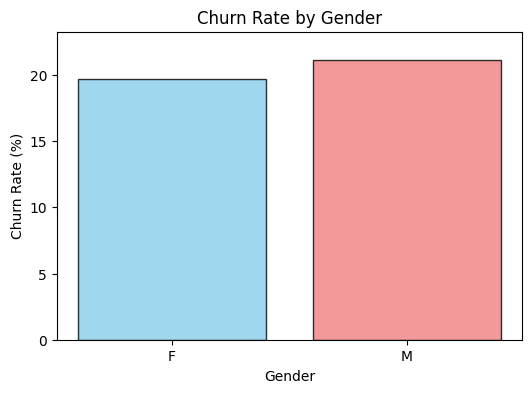

In [8]:
# Churn Rate by Gender

# Merge datasets on CustomerID
df = pd.merge(df_demo, df_churn, on='CustomerID')

# Calculate churn rates by gender
churn_rate = df.groupby('Gender')['ChurnStatus'].mean()*100
print("Churn Rate by Gender:\n", churn_rate)

plt.figure(figsize=(6,4))
genders = churn_rate.index
rates = churn_rate.values

plt.bar(genders, rates, color=['skyblue', 'lightcoral'], alpha=0.8, edgecolor='black', linewidth=1)
plt.title('Churn Rate by Gender')
plt.ylabel('Churn Rate (%)')
plt.xlabel('Gender')
plt.ylim(0, max(rates)*1.1)

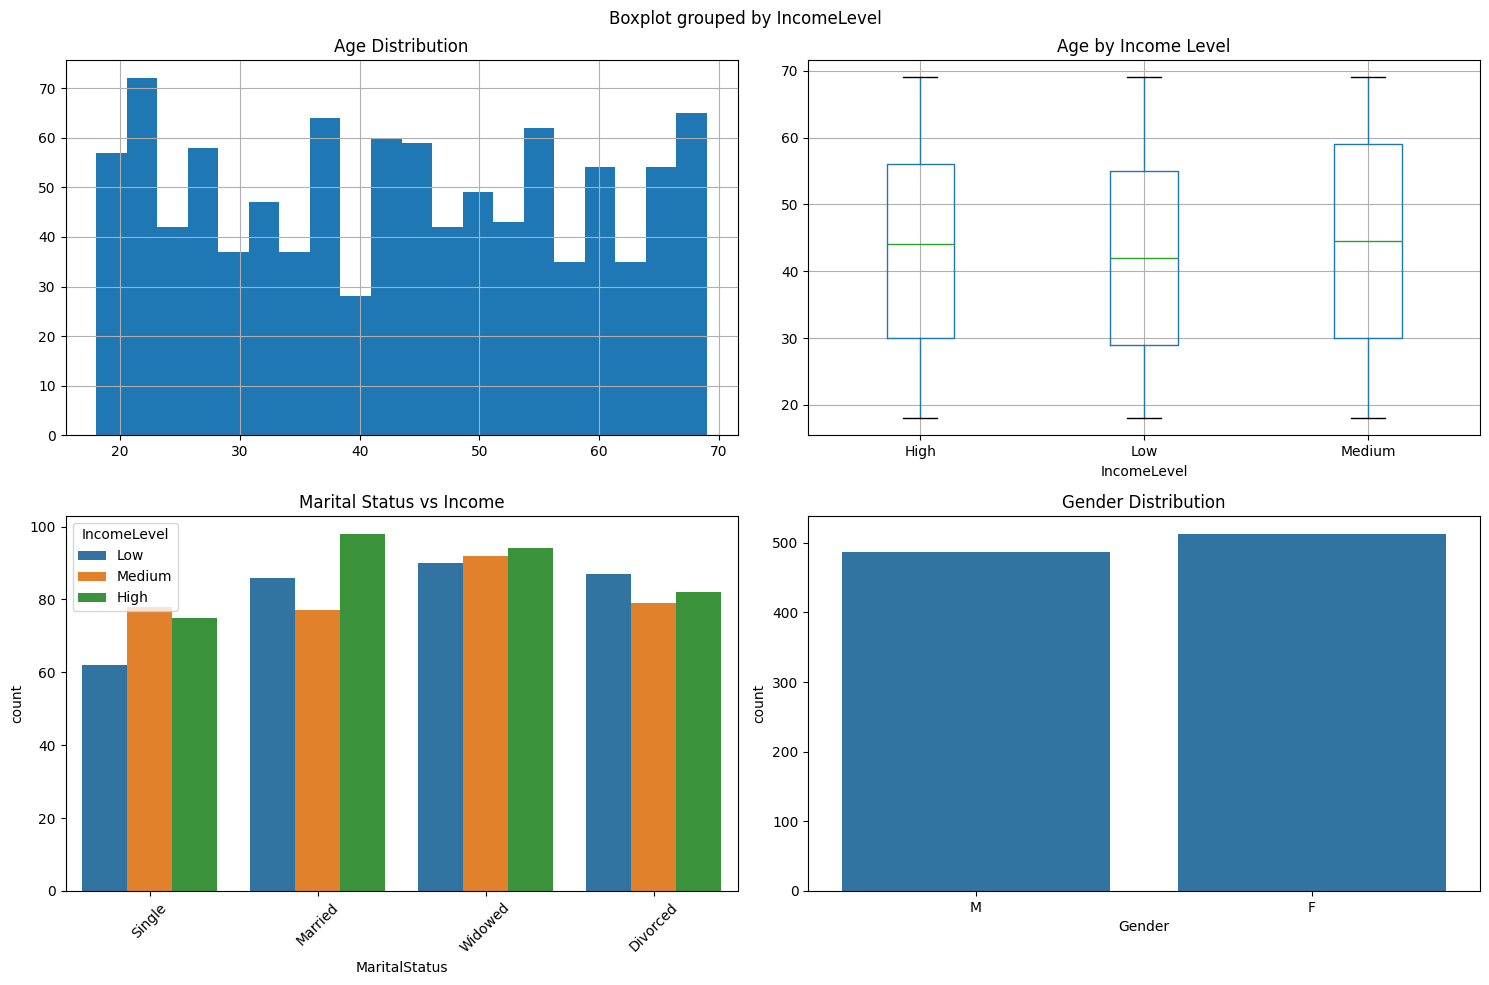

In [9]:
# 2.Demographics EDA
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
df_demo['Age'].hist(bins=20, ax=axes[0,0])
axes[0,0].set_title('Age Distribution')
df_demo.boxplot(column='Age', by='IncomeLevel', ax=axes[0,1])
axes[0,1].set_title('Age by Income Level')

sns.countplot(data=df_demo, x='MaritalStatus', hue='IncomeLevel', ax=axes[1,0])
axes[1,0].tick_params(axis='x', rotation=45)
axes[1,0].set_title('Marital Status vs Income')

sns.countplot(data=df_demo, x='Gender', ax=axes[1,1])
axes[1,1].set_title('Gender Distribution')
plt.tight_layout()
plt.show()

   CustomerID  AmountSpent  ChurnStatus
0           1    416.50000            0
1           2    221.06000            1
2           3    283.83000            0
3           4    183.45800            0
4           5    250.18625            0


<Axes: xlabel='ChurnStatus', ylabel='AmountSpent'>

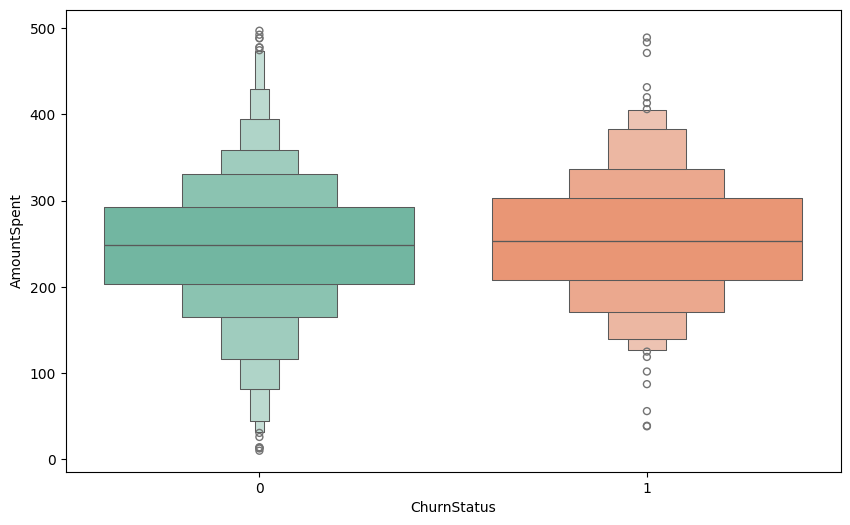

In [10]:
# Spending patterns & Churn

cust_spending = df_trans.groupby('CustomerID')['AmountSpent'].mean().reset_index()

# Merge churn status (adjust column name if needed)
cust_spending = cust_spending.merge(
    df_churn[['CustomerID', 'ChurnStatus']],
    on='CustomerID',
    how='inner'
)
print(cust_spending.head())

plt.figure(figsize=(10,6))
sns.boxenplot(data=cust_spending, x= 'ChurnStatus', y='AmountSpent', palette = "Set2")


Transaction Summary:
        total_spend    avg_spend  trans_count  trans_count_id
count  1000.000000  1000.000000  1000.000000     1000.000000
mean   1267.074950   248.806430     5.054000        5.054000
std     738.590013    79.372717     2.603433        2.603433
min       9.800000     9.800000     1.000000        1.000000
25%     626.685000   203.730000     3.000000        3.000000
50%    1232.880000   250.125000     5.000000        5.000000
75%    1791.902500   295.022500     7.000000        7.000000
max    3386.040000   496.990000     9.000000        9.000000


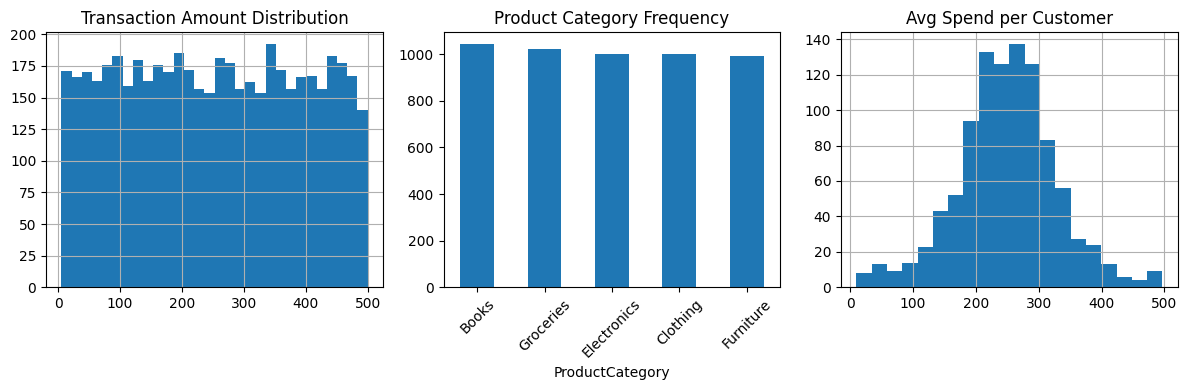

In [11]:
# 3. Transaction Analysis
df_trans_agg = df_trans.groupby('CustomerID').agg({
    'AmountSpent': ['sum', 'mean', 'count'],
    'TransactionID': 'count'
}).round(2)
df_trans_agg.columns = ['total_spend', 'avg_spend', 'trans_count', 'trans_count_id']
print("Transaction Summary:\n", df_trans_agg.describe())

plt.figure(figsize=(12, 4))
plt.subplot(1, 3, 1)
df_trans['AmountSpent'].hist(bins=30)
plt.title('Transaction Amount Distribution')

plt.subplot(1, 3, 2)
df_trans['ProductCategory'].value_counts().plot(kind='bar')
plt.title('Product Category Frequency')
plt.xticks(rotation=45)

plt.subplot(1, 3, 3)
df_trans_agg['avg_spend'].hist(bins=20)
plt.title('Avg Spend per Customer')
plt.tight_layout()
plt.show()

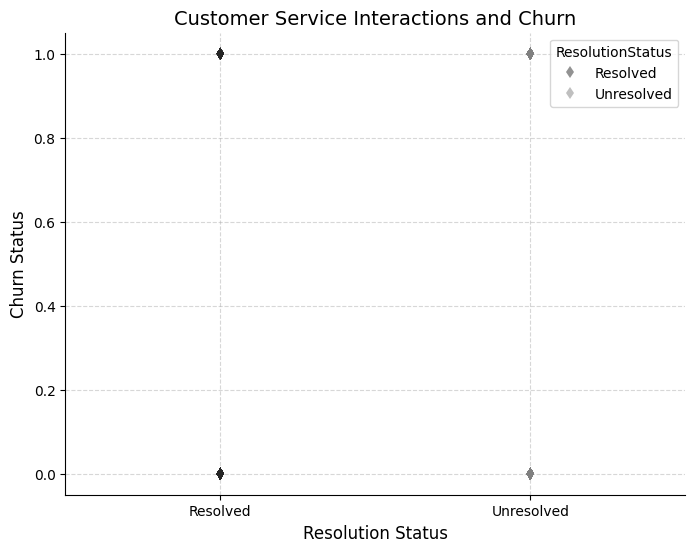

In [12]:
# transaction status and churn

df_interaction = pd.merge(df_service, df_churn, on="CustomerID",how='inner')
plt.figure(figsize=(8,6))
sns.stripplot(
    data=df_interaction,
    x='ResolutionStatus',
    y='ChurnStatus',
    hue = 'ResolutionStatus',
    legend =True,
    jitter=False,        # Slight jitter helps you see if there are MANY dots vs just one
    marker='d',         # 'd' creates the diamond shape seen in your image
    color='grey',     # Dark grey/black color
    alpha=0.5,          # Transparency helps show density where points overlap
    size=6
)

plt.title('Customer Service Interactions and Churn', fontsize=14)
plt.ylabel('Churn Status', fontsize=12)
plt.xlabel('Resolution Status', fontsize=12)

plt.yticks([0, 0.2, 0.4, 0.6, 0.8, 1.0])
plt.ylim(-0.05, 1.05)

plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.grid(axis='x', linestyle='--', alpha=0.5)

# Remove top and right borders (spines) for the clean look
sns.despine()

plt.show()

Online Activity Summary:
count    1000.000000
mean       25.912000
std        14.055953
min         1.000000
25%        13.750000
50%        27.000000
75%        38.000000
max        49.000000
Name: LoginFrequency, dtype: float64

Service Resolution Rate:
ResolutionStatus
Resolved      0.521956
Unresolved    0.478044
Name: proportion, dtype: float64


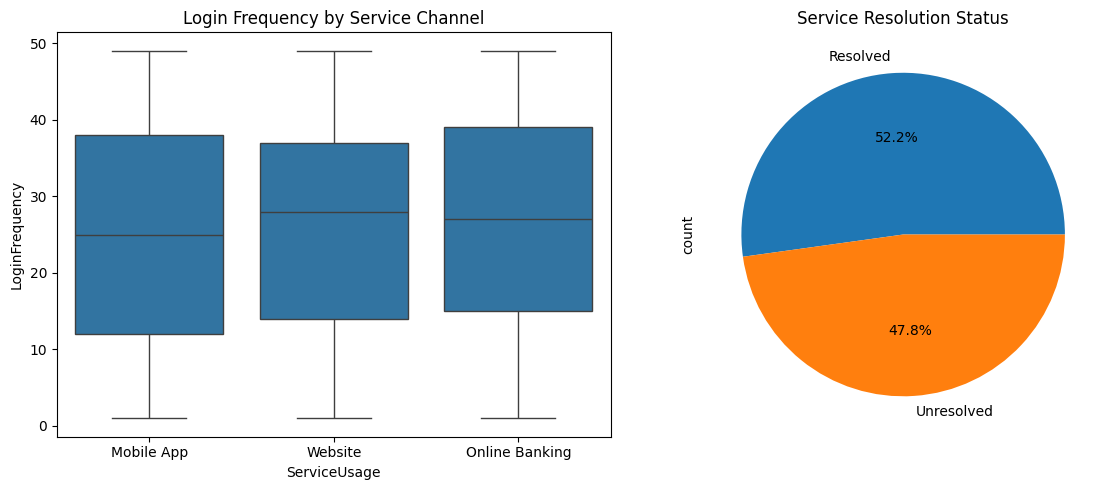

In [13]:
# 4. Online Activity & Service
print("Online Activity Summary:")
print(df_online['LoginFrequency'].describe())
print("\nService Resolution Rate:")
print(df_service['ResolutionStatus'].value_counts(normalize=True))

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.boxplot(data=df_online, x='ServiceUsage', y='LoginFrequency', ax=axes[0])
axes[0].set_title('Login Frequency by Service Channel')

df_service['ResolutionStatus'].value_counts().plot(kind='pie', ax=axes[1], autopct='%1.1f%%')
axes[1].set_title('Service Resolution Status')
plt.tight_layout()
plt.show()


In [14]:
# Check for logical anomalies
print("Sanity Checks:")

# 1. Check Age (Demographics table)
if 'Age' in df_demo.columns:
    print(f"Min Age: {df_demo['Age'].min()}")

# 2. Check Transaction Amount
if 'AmountSpent' in df_trans.columns:
    print(f"Min Amount: {df_trans['AmountSpent'].min()}")
else:
    print(f"Column not found. Available columns: {df_trans.columns.tolist()}")

# 3. Check Gender
if 'Gender' in df_demo.columns:
    print(f"Gender unique values: {df_demo['Gender'].unique()}")

if 'LoginFrequency' in df_online:
    print(f"Login Frequency value: {df_online['LoginFrequency'].min()}")

Sanity Checks:
Min Age: 18
Min Amount: 5.18
Gender unique values: ['M' 'F']
Login Frequency value: 1


### Feature Egineering

In [15]:
# --- A. Engineer Transaction Features ---
# We group by CustomerID to get the total spend and count of transactions
trans_features = df_trans.groupby('CustomerID').agg(
    Avg_Spend=('AmountSpent', 'mean'),
    Total_Spend=('AmountSpent', 'sum'),
    Transaction_Count=('TransactionID', 'count')
).reset_index()

print(trans_features.head())

   CustomerID  Avg_Spend  Total_Spend  Transaction_Count
0           1  416.50000       416.50                  1
1           2  221.06000      1547.42                  7
2           3  283.83000      1702.98                  6
3           4  183.45800       917.29                  5
4           5  250.18625      2001.49                  8


In [16]:
# --- B. Engineer Service Features ---
# 1. Count total interactions per customer
service_features = df_service.groupby('CustomerID').size().reset_index(name='Service_Calls')

# 2. Calculate "Unresolved" Count (High risk indicator)
# Create a helper column: 1 if Unresolved, 0 if Resolved
df_service['Is_Unresolved'] = df_service['ResolutionStatus'].apply(lambda x: 1 if x == 'Unresolved' else 0)
unresolved_stats = df_service.groupby('CustomerID')['Is_Unresolved'].sum().reset_index(name='Unresolved_Count')

# Merge the two service stats together
service_features = pd.merge(service_features, unresolved_stats, on='CustomerID')
print(service_features.head())

   CustomerID  Service_Calls  Unresolved_Count
0           1              1                 0
1           2              1                 0
2           3              1                 0
3           4              2                 1
4           6              1                 0


In [17]:
# --- C. Create the Master Dataset ---
# Start with Demographics
df_final = df_demo.copy()

# Join Churn Status (Target Variable)
df_final = pd.merge(df_final, df_churn, on='CustomerID', how='inner')

# Join Transaction Features
df_final = pd.merge(df_final, trans_features, on='CustomerID', how='left')

# Join Service Features
df_final = pd.merge(df_final, service_features, on='CustomerID', how='left')

# Join Online Activity
df_final = pd.merge(df_final, df_online[['CustomerID', 'LoginFrequency', 'ServiceUsage']], on='CustomerID', how='left')

print(df_final.head())

   CustomerID  Age Gender MaritalStatus IncomeLevel  ChurnStatus  Avg_Spend  \
0           1   62      M        Single         Low            0  416.50000   
1           2   65      M       Married         Low            1  221.06000   
2           3   18      M        Single         Low            0  283.83000   
3           4   21      M       Widowed         Low            0  183.45800   
4           5   21      M      Divorced      Medium            0  250.18625   

   Total_Spend  Transaction_Count  Service_Calls  Unresolved_Count  \
0       416.50                  1            1.0               0.0   
1      1547.42                  7            1.0               0.0   
2      1702.98                  6            1.0               0.0   
3       917.29                  5            2.0               1.0   
4      2001.49                  8            NaN               NaN   

   LoginFrequency ServiceUsage  
0              34   Mobile App  
1               5      Website  
2    

In [18]:
# --- D. Final Cleanup ---
# Left joins create NaNs for customers with NO history. Fill them with 0.
df_final.fillna(0, inplace=True)

print("Feature Engineering Complete.")
print(f"Final Dataset Shape: {df_final.shape}")
print(df_final.head())


Feature Engineering Complete.
Final Dataset Shape: (1000, 13)
   CustomerID  Age Gender MaritalStatus IncomeLevel  ChurnStatus  Avg_Spend  \
0           1   62      M        Single         Low            0  416.50000   
1           2   65      M       Married         Low            1  221.06000   
2           3   18      M        Single         Low            0  283.83000   
3           4   21      M       Widowed         Low            0  183.45800   
4           5   21      M      Divorced      Medium            0  250.18625   

   Total_Spend  Transaction_Count  Service_Calls  Unresolved_Count  \
0       416.50                  1            1.0               0.0   
1      1547.42                  7            1.0               0.0   
2      1702.98                  6            1.0               0.0   
3       917.29                  5            2.0               1.0   
4      2001.49                  8            0.0               0.0   

   LoginFrequency ServiceUsage  
0        

In [19]:
# Outlier Detection

cols_to_cap = ['Avg_Spend', 'Total_Spend', 'Transaction_Count']

print("--- Capping Outliers at 99th Percentile ---")

for col in cols_to_cap:
    if col in df_final.columns:
        upper_limit = df_final[col].quantile(0.99)
        outlier_count = df_final[df_final[col] > upper_limit].shape[0]
        print(f"{col}: Found {outlier_count} outliers above {upper_limit:.2f}")
        df_final[col] = np.where(df_final[col] > upper_limit, upper_limit, df_final[col])
print("\nOutlier treatment complete. Extreme values capped.")
print(df_final[cols_to_cap].describe())

--- Capping Outliers at 99th Percentile ---
Avg_Spend: Found 10 outliers above 471.23
Total_Spend: Found 10 outliers above 2844.56
Transaction_Count: Found 0 outliers above 9.00

Outlier treatment complete. Extreme values capped.
         Avg_Spend  Total_Spend  Transaction_Count
count  1000.000000  1000.000000        1000.000000
mean    248.678305  1264.396270           5.054000
std      78.997926   732.183523           2.603433
min       9.800000     9.800000           1.000000
25%     203.734167   626.685000           3.000000
50%     250.121458  1232.880000           5.000000
75%     295.023854  1791.902500           7.000000
max     471.231400  2844.560000           9.000000


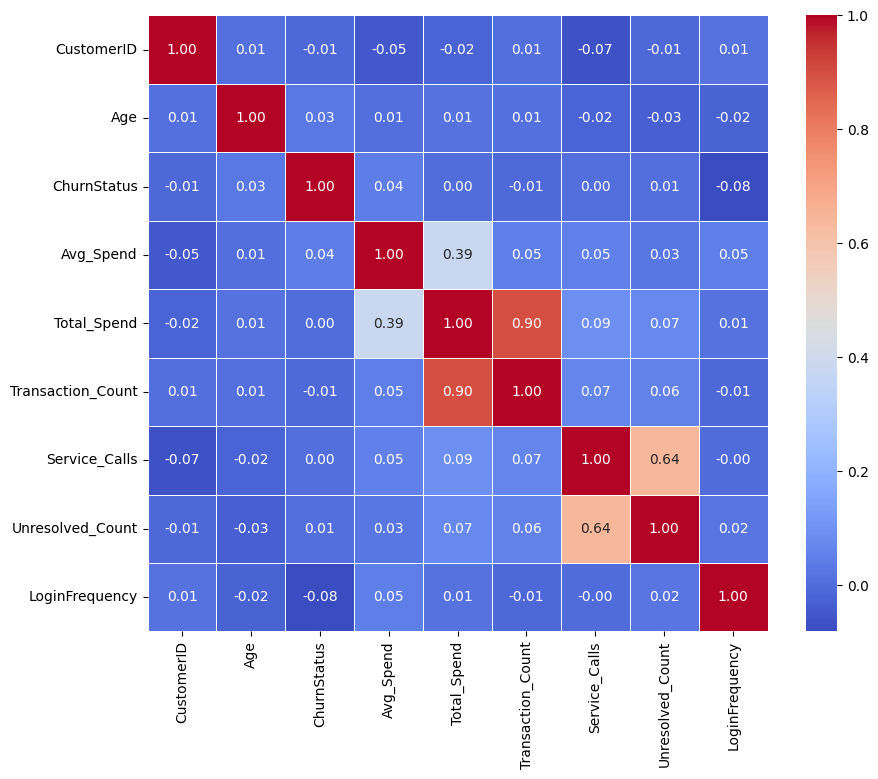

Top Correlated Features with Churn:
ChurnStatus          1.000000
Avg_Spend            0.044900
Age                  0.029407
Unresolved_Count     0.005132
Service_Calls        0.004841
Total_Spend          0.000795
Transaction_Count   -0.008598
CustomerID          -0.011528
LoginFrequency      -0.081615
Name: ChurnStatus, dtype: float64


In [22]:
# Correlation Matrix
numerical_df = df_final.select_dtypes(include=['number'])

corr_matrix = numerical_df.corr()
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.show()
print("Top Correlated Features with Churn:")
print(corr_matrix['ChurnStatus'].sort_values(ascending=False))

In [23]:
# Spliting the target and features

X = df_final.drop(['CustomerID', 'ChurnStatus'], axis=1)
y = df_final['ChurnStatus']

cat_cols = X.select_dtypes(include=['object']).columns.tolist()
num_cols = X.select_dtypes(include=['number']).columns.tolist()
print(f"Categorical Columns to Encode: {cat_cols}")
print(f"Numerical Columns to Scale: {num_cols}")

# One-Hot Encoding
X_processed = pd.get_dummies(X, columns=cat_cols, drop_first=True)
X_processed = X_processed.replace({True: 1, False: 0})
print(X_processed.head())

Categorical Columns to Encode: ['Gender', 'MaritalStatus', 'IncomeLevel', 'ServiceUsage']
Numerical Columns to Scale: ['Age', 'Avg_Spend', 'Total_Spend', 'Transaction_Count', 'Service_Calls', 'Unresolved_Count', 'LoginFrequency']
   Age  Avg_Spend  Total_Spend  Transaction_Count  Service_Calls  \
0   62  416.50000       416.50                1.0            1.0   
1   65  221.06000      1547.42                7.0            1.0   
2   18  283.83000      1702.98                6.0            1.0   
3   21  183.45800       917.29                5.0            2.0   
4   21  250.18625      2001.49                8.0            0.0   

   Unresolved_Count  LoginFrequency  Gender_M  MaritalStatus_Married  \
0               0.0              34         1                      0   
1               0.0               5         1                      1   
2               0.0               3         1                      0   
3               1.0               2         1                      0   
4

In [24]:
# Split the Data
X_train, X_test, y_train, y_test = train_test_split(X_processed, y, random_state=42, test_size=0.2)

print("Original Training Shape:", X_train.shape)
print("Original Class Distribution:\n", y_train.value_counts())
print(X_test.shape)

Original Training Shape: (800, 15)
Original Class Distribution:
 ChurnStatus
0    646
1    154
Name: count, dtype: int64
(200, 15)


In [25]:
# Standardization (Scaling numbers to same range)
scaler = StandardScaler()
X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test[num_cols] = scaler.transform(X_test[num_cols])

In [26]:
# DataBalancing(SMOTE)

smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)
print("Resampled Training Shape:", X_train_resampled.shape)
print("Resampled Class Distribution:\n", y_train_resampled.value_counts())


Resampled Training Shape: (1292, 15)
Resampled Class Distribution:
 ChurnStatus
0    646
1    646
Name: count, dtype: int64



Logistic Regression Model Metrics(Threshold: 0.25):
Accuracy: 0.38
Classification Report:
              precision    recall  f1-score   support

           0       0.77      0.25      0.37       150
           1       0.26      0.78      0.39        50

    accuracy                           0.38       200
   macro avg       0.51      0.51      0.38       200
weighted avg       0.64      0.38      0.38       200

ROC AUC Score: 0.5095999999999999


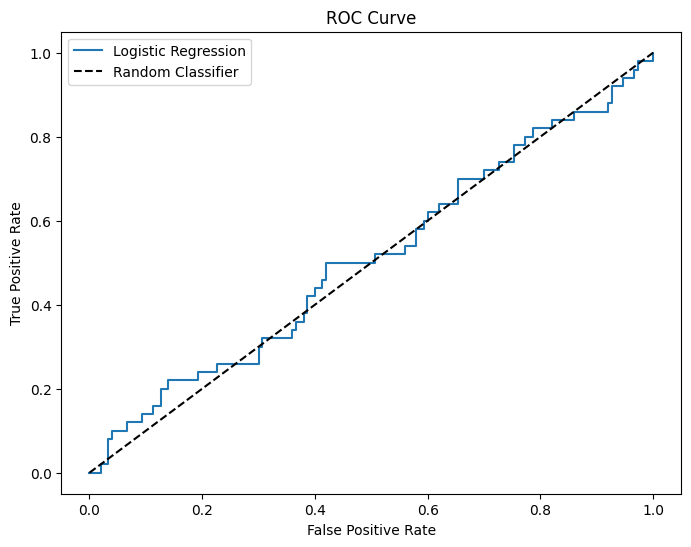

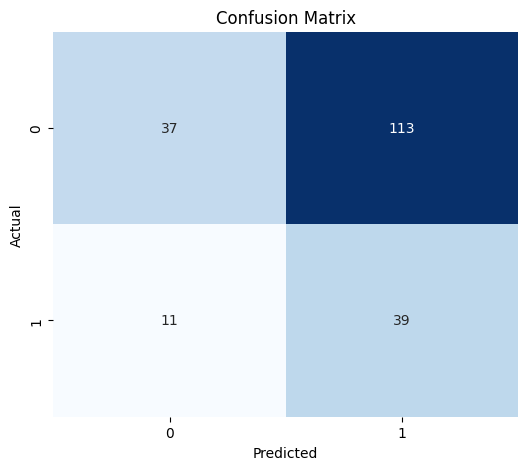

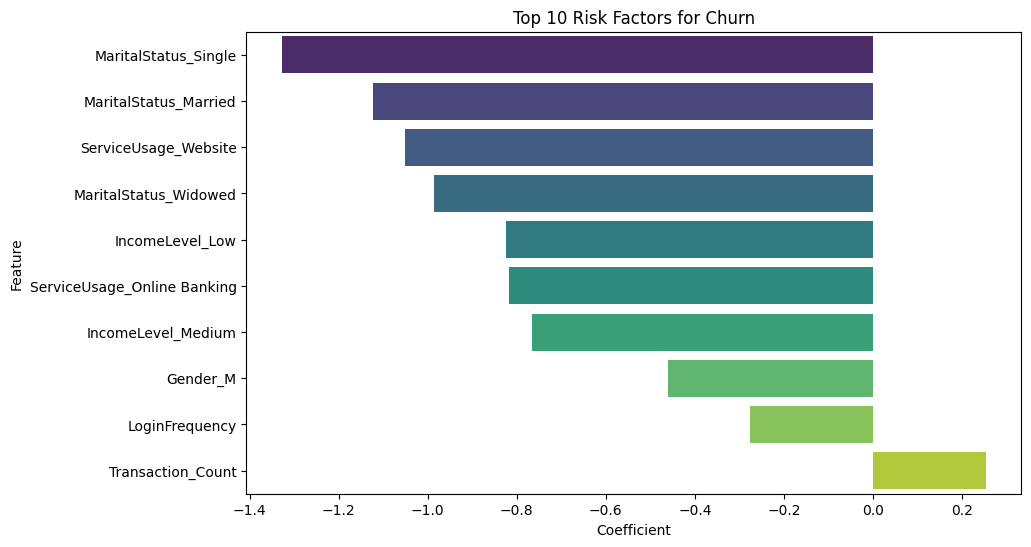


--- Top Risk Factors (Positive = Increases Churn) ---
                  Feature  Coefficient  Abs_Coefficient
9    MaritalStatus_Single    -1.327869         1.327869
8   MaritalStatus_Married    -1.122313         1.122313
14   ServiceUsage_Website    -1.050481         1.050481
10  MaritalStatus_Widowed    -0.984769         0.984769
11        IncomeLevel_Low    -0.824044         0.824044


In [30]:
# logistic model

logreg = LogisticRegression(max_iter=1000, random_state=42)
logreg.fit(X_train_resampled, y_train_resampled)
y_probs_log = logreg.predict_proba(X_test)[:, 1]

custom_threshold = 0.25
y_pred_log = (y_probs_log >= custom_threshold).astype(int)

print(f"\nLogistic Regression Model Metrics(Threshold: {custom_threshold}):")
print(f"Accuracy: {accuracy_score(y_test, y_pred_log)}")
print(f"Classification Report:\n{classification_report(y_test, y_pred_log)}")
print(f"ROC AUC Score: {roc_auc_score(y_test, y_probs_log)}")
plt.figure(figsize=(8, 6))
fpr, tpr, thresholds = roc_curve(y_test, y_probs_log)
plt.plot(fpr, tpr, label='Logistic Regression')
plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()

# Confusion Matrix
plt.figure(figsize=(6, 5))
sns.heatmap(confusion_matrix(y_test, y_pred_log), annot=True, fmt='d', cmap='Blues', cbar=False)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

# Feature Coefficients (Risk Factors)
coeffs = pd.DataFrame({'Feature': X_train_resampled.columns, 'Coefficient': logreg.coef_[0]})
coeffs['Abs_Coefficient'] = coeffs['Coefficient'].abs()
coeffs = coeffs.sort_values(by='Abs_Coefficient', ascending=False)
plt.figure(figsize=(10, 6))
sns.barplot(x='Coefficient', y='Feature', data=
            coeffs.head(10), palette='viridis')
plt.title('Top 10 Risk Factors for Churn')
plt.show()

print("\n--- Top Risk Factors (Positive = Increases Churn) ---")
print(coeffs.head(5))



Random Forest Model Metrics(Threshold: 0.25):
Accuracy: 0.435
Classification Report:
              precision    recall  f1-score   support

           0       0.75      0.37      0.50       150
           1       0.25      0.62      0.35        50

    accuracy                           0.43       200
   macro avg       0.50      0.50      0.43       200
weighted avg       0.62      0.43      0.46       200

ROC AUC Score: 0.5426666666666667


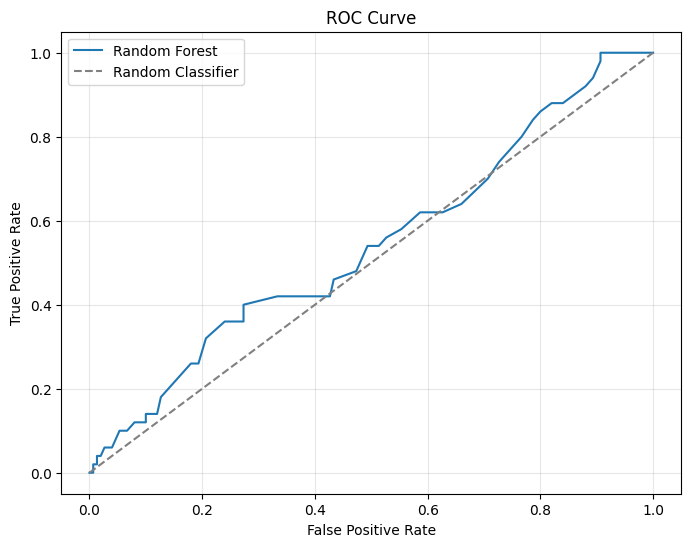

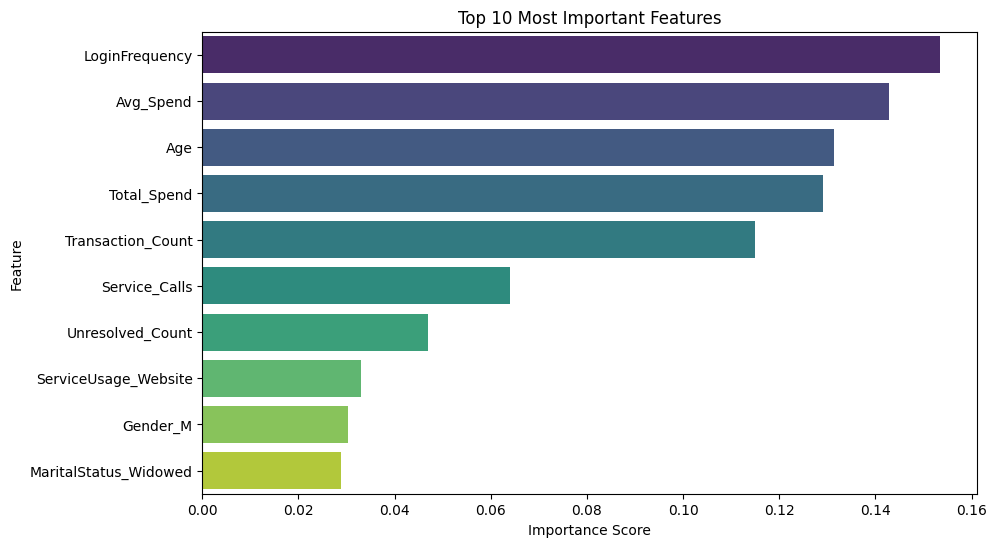

In [41]:
# Random Forest

rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train_resampled, y_train_resampled)
y_probs_rf = rf_model

# confidence score
y_probs_rf = rf_model.predict_proba(X_test)[:, 1]

# Apply threshold to .25
custom_threshold = 0.25
y_pred_rf = (y_probs_rf >= custom_threshold).astype(int)

# Evaluate Performance
print(f"\nRandom Forest Model Metrics(Threshold: {custom_threshold}):")
print(f"Accuracy: {accuracy_score(y_test, y_pred_rf)}")

print(f"Classification Report:\n{classification_report(y_test, y_pred_rf)}")
print(f"ROC AUC Score: {roc_auc_score(y_test, y_probs_rf)}")

plt.figure(figsize=(8, 6))
fpr, tpr, thresholds = roc_curve(y_test, y_probs_rf)

plt.plot(fpr, tpr, label='Random Forest')
plt.plot([0,1], [0,1],color='gray', linestyle='--', label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Feature Importance
feature_importances = pd.DataFrame({'Feature': X_train_resampled.columns, 'Importance': rf_model.feature_importances_})
feature_importances = feature_importances.sort_values(by='Importance', ascending=False)
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importances.head(10), palette='viridis')
plt.title('Top 10 Most Important Features')
plt.xlabel('Importance Score')
plt.ylabel('Feature')
plt.show()

# Generating submission csv
submission_df = pd.DataFrame({'CustomerID': X_test.index, 'Predicted_Churn': y_pred_rf})
submission_df.to_csv('submission.csv', index=False)


XGBoost Model Metrics(Threshold: 0.25):
Accuracy: 0.65
Classification Report:
              precision    recall  f1-score   support

           0       0.78      0.75      0.76       150
           1       0.32      0.36      0.34        50

    accuracy                           0.65       200
   macro avg       0.55      0.55      0.55       200
weighted avg       0.66      0.65      0.66       200

ROC AUC Score: 0.5785333333333333


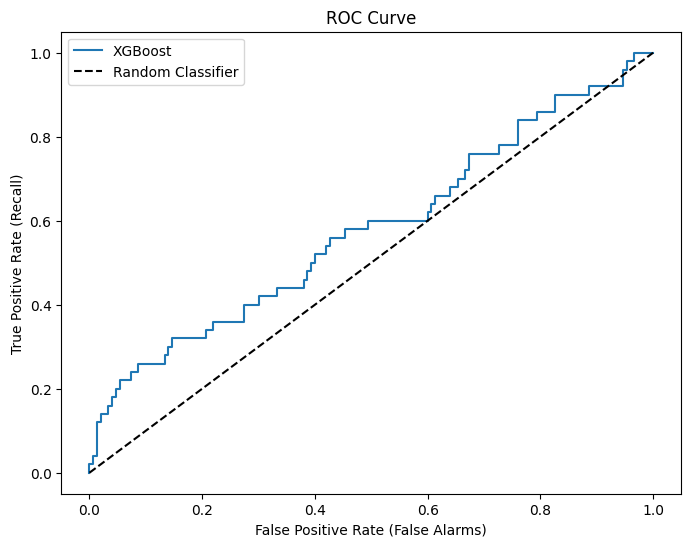

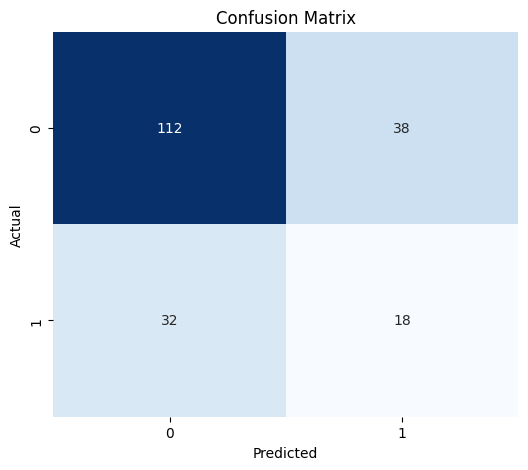

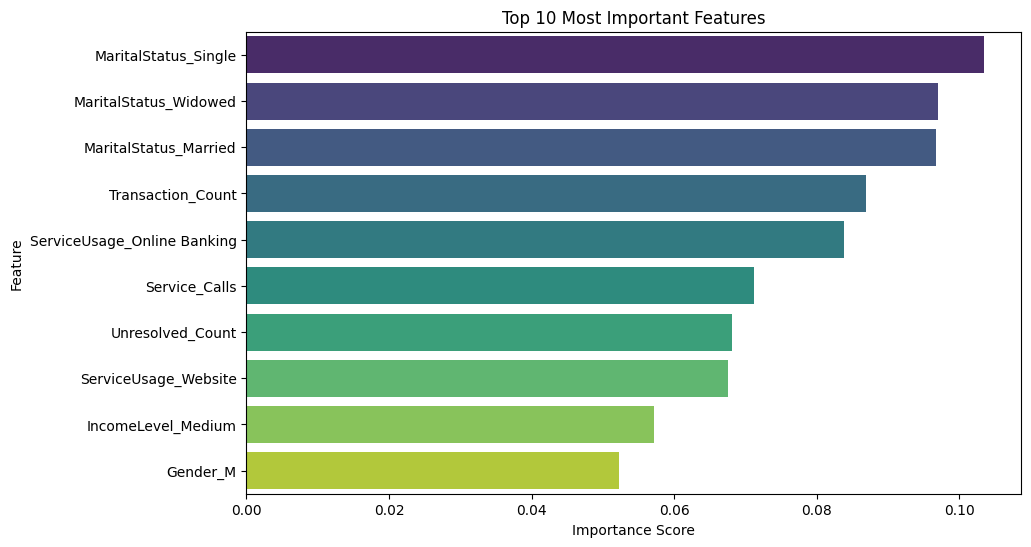

In [44]:
# XGB
from xgboost import XGBClassifier
xgb_model = XGBClassifier(n_estimators=100, random_state=42)
xgb_model.fit(X_train_resampled, y_train_resampled)
y_probs_xgb = xgb_model.predict_proba(X_test)[:, 1]

custom_threshold = 0.25
y_pred_xgb = (y_probs_xgb >= custom_threshold).astype(int)

print(f"\nXGBoost Model Metrics(Threshold: {custom_threshold}):")
print(f"Accuracy: {accuracy_score(y_test, y_pred_xgb)}")
print(f"Classification Report:\n{classification_report(y_test, y_pred_xgb)}")
print(f"ROC AUC Score: {roc_auc_score(y_test, y_probs_xgb)}")

plt.figure(figsize=(8, 6))
fpr, tpr, thresholds = roc_curve(y_test, y_probs_xgb)
plt.plot(fpr, tpr, label='XGBoost')
plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier')
plt.xlabel('False Positive Rate (False Alarms)')
plt.ylabel('True Positive Rate (Recall)')
plt.title('ROC Curve')
plt.legend()
plt.show()

# Confusion Matrix
plt.figure(figsize=(6, 5))
sns.heatmap(confusion_matrix(y_test, y_pred_xgb), annot=True, fmt='d', cmap='Blues', cbar=False)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

# Feature Importance
feature_importances = pd.DataFrame({'Feature': X_train_resampled.columns, 'Importance': xgb_model.feature_importances_})
feature_importances = feature_importances.sort_values(by='Importance', ascending=False)
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importances.head(10), palette='viridis')
plt.title('Top 10 Most Important Features')
plt.xlabel('Importance Score')
plt.ylabel('Feature')
plt.show()


Best Hyperparameters: {'class_weight': 'balanced', 'max_depth': None, 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 200}

Best Model Metrics(Threshold: 0.25):
Accuracy: 0.425
Classification Report:
              precision    recall  f1-score   support

           0       0.78      0.33      0.46       150
           1       0.26      0.72      0.39        50

    accuracy                           0.42       200
   macro avg       0.52      0.52      0.42       200
weighted avg       0.65      0.42      0.44       200

ROC AUC Score: 0.5653333333333334


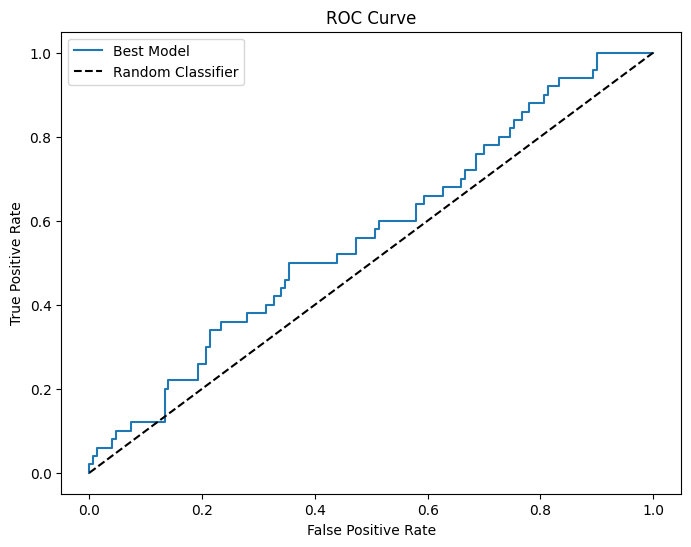

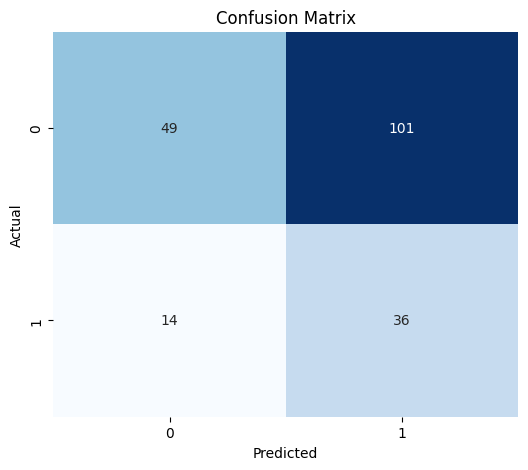


True Negatives: 49, False Positives: 101, Missed Churners(False Negatives): 14, Caught Churners(True Positives): 36


In [45]:
# Hyperparameter Tunning (GridSearchCV)

param_grid = {
    'n_estimators': [50, 100,200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [2,5,10],
    'class_weight': ['balanced', 'balanced_subsample']
}

grid_search = GridSearchCV(estimator=rf_model, param_grid=param_grid, cv=5, scoring='recall', n_jobs=-1)
grid_search.fit(X_train_resampled, y_train_resampled)

best_params = grid_search.best_params_
print(f"Best Hyperparameters: {best_params}")

best_model = grid_search.best_estimator_
y_probs_best = best_model.predict_proba(X_test)[:, 1]
y_pred_best = (y_probs_best >= custom_threshold).astype(int)

print(f"\nBest Model Metrics(Threshold: {custom_threshold}):")
print(f"Accuracy: {accuracy_score(y_test, y_pred_best)}")

print(f"Classification Report:\n{classification_report(y_test, y_pred_best)}")

print(f"ROC AUC Score: {roc_auc_score(y_test, y_probs_best)}")
plt.figure(figsize=(8, 6))
fpr, tpr, thresholds = roc_curve(y_test, y_probs_best)
plt.plot(fpr, tpr, label='Best Model')
plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()

# confusion matrix
plt.figure(figsize=(6, 5))
sns.heatmap(confusion_matrix(y_test, y_pred_best), annot=True, fmt='d', cmap='Blues', cbar=False)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

# print the raw number
tn, fp, fn, tp = confusion_matrix(y_test, y_pred_best).ravel()
print(f"\nTrue Negatives: {tn}, False Positives: {fp}, Missed Churners(False Negatives): {fn}, Caught Churners(True Positives): {tp}")

#Feature Importance
feature_importances= pd.DataFrame({'Feature': X_train_resampled.columns, 'Importance': best_model.feature_importances_})
feature_importances = feature_importances.sort_values(by='Importance', ascending=False)

print("\n--- Top Risk Factors (Positive = Increases Churn) ---")
print(feature_importances.head(10))

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importances.head(10), palette='viridis')
plt.title('Top 10 Most Important Features')
plt.xlabel('Importance Score')
plt.ylabel('Feature')
plt.show()

